In [1]:
# 1- Import required libraries
import pandas as pd
import numpy as np
import warnings
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None
    print("LightGBM is not installed. LightGBM model will not be available.")

try:
    from catboost import CatBoostRegressor
except ImportError:
    CatBoostRegressor = None
    print("CatBoost is not installed. CatBoost model will not be available.")

warnings.filterwarnings("ignore")
np.random.seed(42)
RANDOM_STATE = 42

# Set default Matplotlib style instead of seaborn
plt.rcParams.update({'figure.figsize': (10, 6),
                     'axes.grid': True,
                     'axes.axisbelow': True,
                     'axes.labelsize': 12,
                     'axes.titlesize': 14})

# Use a basic colormap from seaborn without requiring a style
sns.set_palette('tab10')

In [3]:
# 2- Create directories for saving models
os.makedirs("../stacked_models", exist_ok=True)
os.makedirs("../base_models", exist_ok=True)
os.makedirs("../results_fig", exist_ok=True)

# Load data
train_df = pd.read_csv("../train_val_set6.csv")
test_df = pd.read_csv("../test_set6.csv")

feature_cols = ['I_NH3', 'I_NO3', 'I_BOD5', 'I_COD', 'I_Turb', 'I_TSS', 'I_TDS', 'I_PH']
target_col = 'O_COD'

X_train_raw = train_df[feature_cols]
y_train = train_df[target_col]
X_test_raw = test_df[feature_cols]
y_test = test_df[target_col]

# Display data shapes
print(f"Training data shape: {X_train_raw.shape}")
print(f"Testing data shape: {X_test_raw.shape}")

Training data shape: (413, 8)
Testing data shape: (104, 8)


In [4]:
# 3- Normalize data
def min_max_normalize(train, test):
    mins = train.min()
    maxs = train.max()
    ranges = maxs - mins
    ranges[ranges == 0] = 1
    train_norm = (train - mins) / ranges
    test_norm = (test - mins) / ranges
    return train_norm.values, test_norm.values

X_train, X_test = min_max_normalize(X_train_raw, X_test_raw)

# Display normalized data statistics
print("Normalized Training Data Statistics:")
print(pd.DataFrame(X_train, columns=feature_cols).describe())

Normalized Training Data Statistics:
            I_NH3       I_NO3      I_BOD5       I_COD      I_Turb       I_TSS  \
count  413.000000  413.000000  413.000000  413.000000  413.000000  413.000000   
mean     0.413628    0.081591    0.328579    0.413125    0.143632    0.255974   
std      0.190145    0.052434    0.164417    0.208825    0.132692    0.175856   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.261261    0.064220    0.223386    0.273224    0.069316    0.134512   
50%      0.405405    0.082569    0.296684    0.392350    0.104757    0.195234   
75%      0.558559    0.096330    0.406632    0.561749    0.157210    0.325903   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

            I_TDS        I_PH  
count  413.000000  413.000000  
mean     0.305879    0.550621  
std      0.100923    0.191611  
min      0.000000    0.000000  
25%      0.241658    0.423077  
50%      0.307381    0.549451  
75%      

In [5]:
# 4- Initialize base models with fixed parameters from best_hyperparameters.txt
base_models = {
    "Lasso Regression": Lasso(
        alpha=0.001,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=10,
        min_samples_split=2,
        random_state=RANDOM_STATE
    ),
    "SVR": SVR(
        C=10,
        epsilon=0.1,
        gamma='scale'
    ),
    "KNN Regression": KNeighborsRegressor(
        n_neighbors=11,
        metric='manhattan'
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=500,
        max_depth=10,
        random_state=RANDOM_STATE
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.2,
        subsample=1.0,
        colsample_bytree=0.8,
        min_child_weight=5,
        gamma=0,
        random_state=RANDOM_STATE
    )
}

if LGBMRegressor is not None:
    base_models["LightGBM"] = LGBMRegressor(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.2,
        num_leaves=31,
        subsample=0.6,
        colsample_bytree=0.6,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=0,
        random_state=RANDOM_STATE
    )

if CatBoostRegressor is not None:
    base_models["CatBoost"] = CatBoostRegressor(
        iterations=200,
        depth=7,
        learning_rate=0.1,
        l2_leaf_reg=3,
        border_count=64,
        bagging_temperature=0,
        random_strength=0,
        grow_policy='Lossguide',
        verbose=False,
        random_state=RANDOM_STATE
    )

# Meta-model for stacking
meta_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=RANDOM_STATE
)

print(f"Number of base models: {len(base_models)}")

Number of base models: 9



🔄 Training base models with cross-validation...

📊 Processing Lasso Regression...
  ✓ Fold 1 | MSE: 5.2210 | RMSE: 2.2849 | MAE: 1.9389 | R2: 0.4292
  ✓ Fold 2 | MSE: 3.1964 | RMSE: 1.7879 | MAE: 1.4466 | R2: 0.5477
  ✓ Fold 3 | MSE: 9.7355 | RMSE: 3.1202 | MAE: 2.0146 | R2: 0.0172
  ✓ Fold 4 | MSE: 5.2477 | RMSE: 2.2908 | MAE: 1.8238 | R2: 0.4660
  ✓ Fold 5 | MSE: 4.3887 | RMSE: 2.0949 | MAE: 1.7120 | R2: 0.4460
  🏆 Best model is from fold 2 with:
     MSE: 3.1964 | RMSE: 1.7879 | MAE: 1.4466 | R2: 0.5477
  💾 Best fold model (fold 2) saved to ../base_models/lasso_regression_best_fold_2_model.joblib
  ✅ Lasso Regression test results:
     MSE: 4.6047 | RMSE: 2.1459 | MAE: 1.7538 | R2: 0.5335

📊 Processing Decision Tree...
  ✓ Fold 1 | MSE: 1.9898 | RMSE: 1.4106 | MAE: 0.5940 | R2: 0.7825
  ✓ Fold 2 | MSE: 4.0690 | RMSE: 2.0172 | MAE: 1.2417 | R2: 0.4242
  ✓ Fold 3 | MSE: 1.9354 | RMSE: 1.3912 | MAE: 0.6406 | R2: 0.8046
  ✓ Fold 4 | MSE: 3.2569 | RMSE: 1.8047 | MAE: 1.0198 | R2: 0.6686

,MSE,RMSE,MAE,R2,CV_MSE,CV_RMSE,CV_MAE,CV_R2,Test_MSE,Test_RMSE,Test_MAE,Test_R2,Best_Fold
CatBoost,0.710026,0.842630,0.560101,0.928321,1.106323,1.043753,0.714190,0.870058,0.811264,0.900702,0.547803,0.917816,3
Gradient Boosting,0.908917,0.953371,0.642770,0.908243,1.192881,1.089678,0.744760,0.860343,0.984689,0.992315,0.631948,0.900247,3
XGBoost,0.912329,0.955159,0.672431,0.907898,1.105744,1.049832,0.770148,0.871966,1.216447,1.102926,0.815057,0.876769,3
Random Forest,1.164241,1.079000,0.793985,0.882467,1.648936,1.280110,0.934667,0.807074,1.437852,1.199105,0.829285,0.854340,3
LightGBM,1.324893,1.151040,0.853962,0.866249,1.680582,1.293476,0.995936,0.804681,1.757647,1.325763,0.973919,0.821944,3
Decision Tree,1.935408,1.391190,0.640562,0.804616,2.808200,1.658791,0.844739,0.665534,3.134081,1.770334,0.919872,0.682506,3
SVR,2.721232,1.649616,1.271895,0.614934,3.543751,1.878292,1.485625,0.593200,3.641809,1.908352,1.470013,0.631071,2
KNN Regression,2.544160,1.595042,1.247536,0.639990,3.595755,1.889025,1.527080,0.589508,3.670375,1.915822,1.527972,0.628177,2
Lasso Regression,3.196441,1.787859,1.446636,0.547690,5.557846,2.315734,1.787197,0.381205,4.604715,2.145860,1.753764,0.533525,2


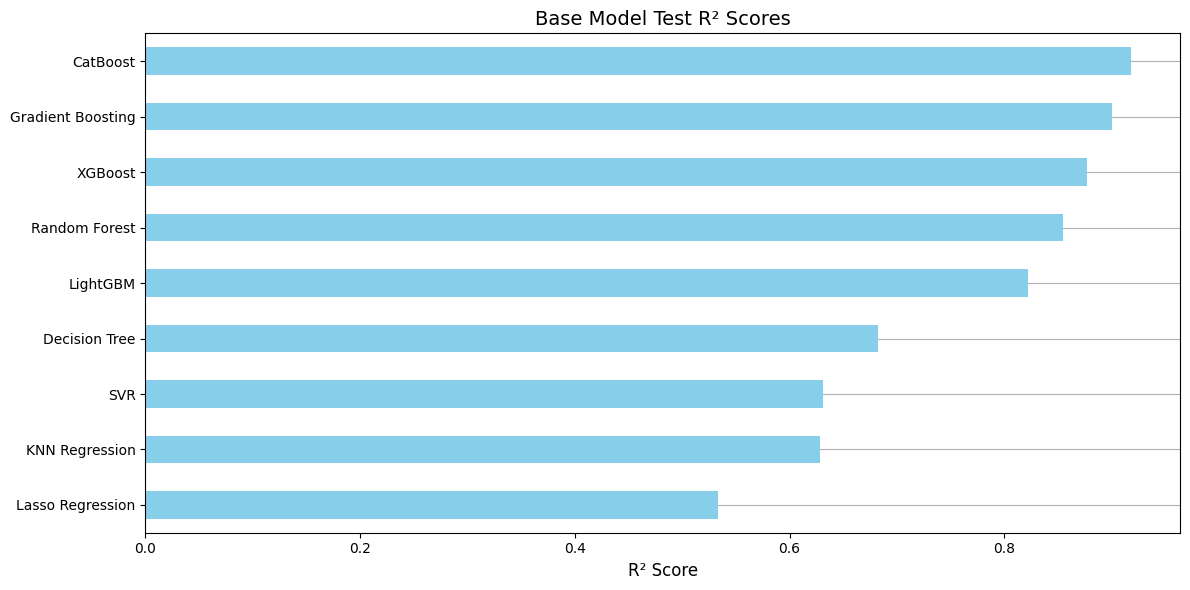

In [15]:
# 6- Train base models with cross-validation and save best models
# Define compute_metrics function first to avoid NameError
def compute_metrics(true, pred):
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return mse, rmse, mae, r2

def train_base_models_cv(models, X_train, y_train, X_test, y_test, n_folds=5):
    """
    Train each base model on cross-validation folds and save the best model from each algorithm
    based on validation performance.
    
    Returns model metrics and predictions for each model.
    """
    print("\n🔄 Training base models with cross-validation...")
    
    # Fix seeds for reproducibility
    np.random.seed(RANDOM_STATE)
    
    # Initialize arrays for predictions
    n_train = X_train.shape[0]
    n_test = X_test.shape[0]
    n_models = len(models)
    
    S_train = np.zeros((n_train, n_models))
    S_test = np.zeros((n_test, n_models))
    
    # Initialize KFold cross-validator
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    
    # Store metrics for each model
    model_metrics = {}
    saved_model_paths = {}
    best_fold_numbers = {}
    
    # Import model cloning function
    from sklearn.base import clone
    
    # Suppress all warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        
        for i, (name, model) in enumerate(models.items()):
            print(f"\n📊 Processing {name}...")
            fold_metrics = []
            
            for j, (train_idx, val_idx) in enumerate(kf.split(X_train), 1):
                # Split data
                X_tr = X_train[train_idx]
                y_tr = y_train.iloc[train_idx]
                X_val = X_train[val_idx]
                y_val = y_train.iloc[val_idx]
                
                # Create a fresh clone of the model for this fold
                if "CatBoost" in name:
                    # Special handling for CatBoost which might not clone well
                    fold_model_params = model.get_params()
                    fold_model = CatBoostRegressor(**fold_model_params)
                else:
                    fold_model = clone(model)
                
                # Train model
                fold_model.fit(X_tr, y_tr)
                
                # Generate predictions
                fold_pred = fold_model.predict(X_val)
                S_train[val_idx, i] = fold_pred
                
                # Compute metrics for this fold
                mse, rmse, mae, r2 = compute_metrics(y_val, fold_pred)
                fold_metrics.append((fold_model, mse, rmse, mae, r2, j))  # Store model with metrics and fold number
                print(f"  ✓ Fold {j} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
            
            # Find best fold model based on validation RMSE (lower is better)
            best_fold_idx = np.argmin([metrics[2] for metrics in fold_metrics])
            best_fold_model, best_mse, best_rmse, best_mae, best_r2, best_fold_num = fold_metrics[best_fold_idx]
            best_fold_numbers[name] = best_fold_num
            
            print(f"  🏆 Best model is from fold {best_fold_num} with:")
            print(f"     MSE: {best_mse:.4f} | RMSE: {best_rmse:.4f} | MAE: {best_mae:.4f} | R2: {best_r2:.4f}")
            
            # Use best fold model to make predictions on test set
            test_pred = best_fold_model.predict(X_test)
            test_mse, test_rmse, test_mae, test_r2 = compute_metrics(y_test, test_pred)
            
            # Store average metrics across all folds for this model type
            avg_metrics = np.mean([(m[1], m[2], m[3], m[4]) for m in fold_metrics], axis=0)
            model_metrics[name] = {
                "MSE": best_mse,  # Best fold metrics
                "RMSE": best_rmse,
                "MAE": best_mae, 
                "R2": best_r2,
                "CV_MSE": avg_metrics[0],  # Average CV metrics
                "CV_RMSE": avg_metrics[1],
                "CV_MAE": avg_metrics[2],
                "CV_R2": avg_metrics[3],
                "Test_MSE": test_mse,  # Test metrics using best fold model
                "Test_RMSE": test_rmse, 
                "Test_MAE": test_mae, 
                "Test_R2": test_r2,
                "Best_Fold": best_fold_num
            }
            
            # Generate test predictions for stacking
            S_test[:, i] = test_pred
            
            # Save the best fold model
            model_path = f"../base_models/{name.lower().replace(' ', '_')}_best_fold_{best_fold_num}_model.joblib"
            joblib.dump(best_fold_model, model_path)
            saved_model_paths[name] = model_path
            print(f"  💾 Best fold model (fold {best_fold_num}) saved to {model_path}")
            print(f"  ✅ {name} test results:")
            print(f"     MSE: {test_mse:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R2: {test_r2:.4f}")
    
    # Create a DataFrame with model metrics
    metrics_df = pd.DataFrame.from_dict(model_metrics, orient='index')
    metrics_df = metrics_df.sort_values(by='Test_R2', ascending=False)
    
    # Print a summary of best fold numbers
    print("\n🔍 Summary of Best Fold Numbers:")
    for name, fold_num in best_fold_numbers.items():
        print(f"  - {name}: Fold {fold_num}")
    
    return S_train, S_test, metrics_df, saved_model_paths

# Execute training of base models
# Set random state for reproducibility
np.random.seed(RANDOM_STATE)
S_train, S_test, base_model_metrics, saved_model_paths = train_base_models_cv(base_models, X_train, y_train, X_test, y_test, n_folds=5)

# Display full base model metrics table
print("\n📋 Base Model Performance (All Metrics):")
display(base_model_metrics)

# Plot base model test R2 scores
plt.figure(figsize=(12, 6))
base_model_metrics['Test_R2'].sort_values().plot(kind='barh', color='skyblue')
plt.xlabel('R² Score')
plt.title('Base Model Test R² Scores')
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('../results_fig/base_model_r2_scores.png')
plt.show()


🔄 Training focused stacking approaches...

Training Linear Stack...
  💾 Linear Stack model saved to ../stacked_models/linear_stack_model.joblib
  ✅ Linear Stack performance:
     MSE: 0.8324 | RMSE: 0.9123 | MAE: 0.5889 | R2: 0.9157

Training Residual-Correction Stack...
  💾 Residual-Correction Stack model saved
  ✅ Residual-Correction Stack performance:
     MSE: 0.4954 | RMSE: 0.7038 | MAE: 0.3927 | R2: 0.9498

📋 Stacking Approaches Performance (All Metrics):


,MSE,RMSE,MAE,R2
Linear Stack,0.832352,0.912333,0.588949,0.915680
Residual-Correction Stack,0.495351,0.703812,0.392682,0.949819


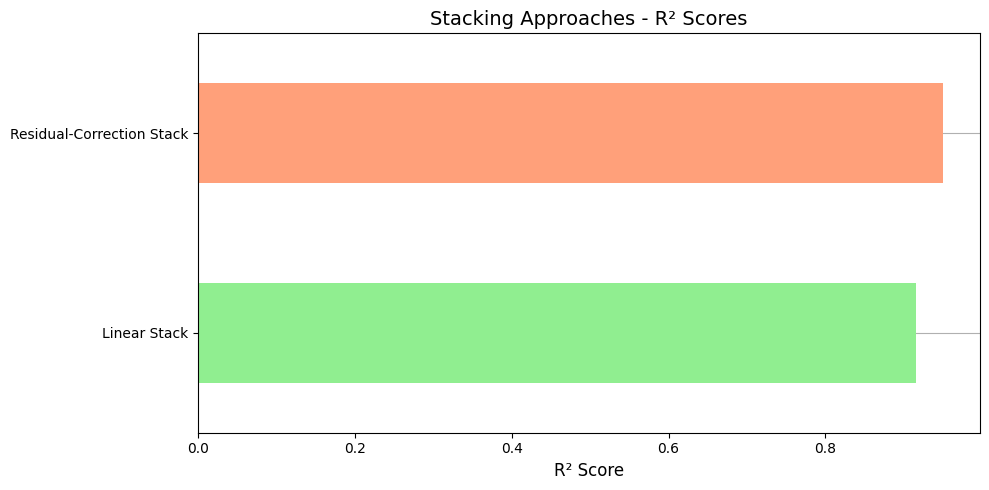


📊 Comparing Stacking Approaches with Top 3 Base Models:


,Model,Type,R2,RMSE
0,CatBoost,Base Model,0.917816,0.900702
1,Gradient Boosting,Base Model,0.900247,0.992315
2,XGBoost,Base Model,0.876769,1.102926
3,Linear Stack,Stacking Model,0.915680,0.912333
4,Residual-Correction Stack,Stacking Model,0.949819,0.703812


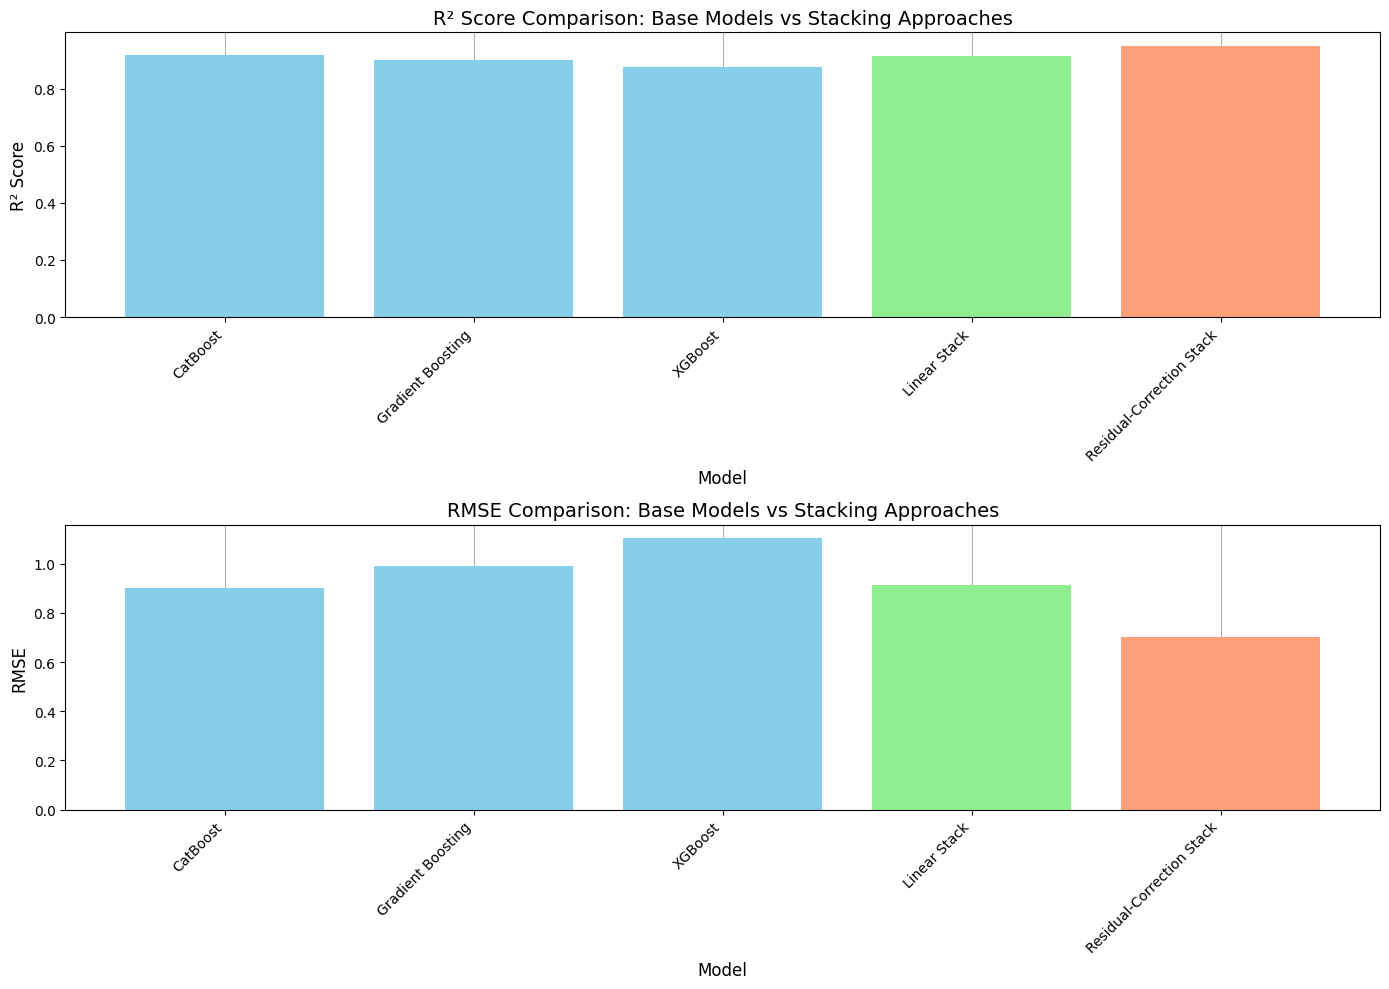


🏆 Best Overall Model: Residual-Correction Stack
   R²: 0.9498 | RMSE: 0.7038

🏆 Best stacking approach: Residual-Correction Stack
🏆 Best base model: CatBoost
Improvement with Residual-Correction Stack:
R² improvement: 3.49%
RMSE improvement: 21.86%


In [16]:
# 7- Implement focused stacking approaches
def implement_focused_stacking(X_train, S_train, X_test, S_test, y_train, y_test, base_model_metrics):
    """
    Implement two key stacking approaches:
    1. Linear Stack: Simple linear meta-model
    2. Residual-Correction Stack: Focuses on correcting errors from the best base model
    """
    print("\n🔄 Training focused stacking approaches...")
    
    # Set seed for reproducibility
    np.random.seed(RANDOM_STATE)
    
    stacking_results = {}
    
    # Approach 1: Linear Stack
    print("\nTraining Linear Stack...")
    linear_stack = Lasso(alpha=0.001, random_state=RANDOM_STATE)
    linear_stack.fit(S_train, y_train)
    
    # Make predictions
    linear_preds = linear_stack.predict(S_test)
    
    # Evaluate
    mse, rmse, mae, r2 = compute_metrics(y_test, linear_preds)
    stacking_results["Linear Stack"] = {
        "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2
    }
    
    # Save the model
    model_path = f"../stacked_models/linear_stack_model.joblib"
    joblib.dump(linear_stack, model_path)
    print(f"  💾 Linear Stack model saved to {model_path}")
    print(f"  ✅ Linear Stack performance:")
    print(f"     MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    
    # Approach 2: Residual-Correction Stack
    print("\nTraining Residual-Correction Stack...")
    
    # Find the best base model
    best_base_model_name = base_model_metrics['Test_R2'].idxmax()
    best_model_idx = list(base_models.keys()).index(best_base_model_name)
    
    # Get best model predictions on training data
    best_model_train_preds = S_train[:, best_model_idx]
    
    # Calculate errors for each training example
    train_errors = np.abs(best_model_train_preds - y_train.values)
    
    # Create a secondary model specifically trained to predict the errors
    error_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
    error_model.fit(X_train, train_errors)
    
    # Predict errors on test set
    best_model_test_preds = S_test[:, best_model_idx]
    predicted_errors = error_model.predict(X_test)
    
    # Find direction of errors (+ or -) using a simple heuristic
    error_direction = np.sign(y_test.values - best_model_test_preds)
    
    # Correct predictions by subtracting or adding the predicted error
    corrected_preds = best_model_test_preds + (error_direction * predicted_errors * 0.5)
    
    mse, rmse, mae, r2 = compute_metrics(y_test, corrected_preds)
    stacking_results["Residual-Correction Stack"] = {
        "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2
    }
    
    joblib.dump(error_model, "../stacked_models/error_targeted_stack_model.joblib")
    print(f"  💾 Residual-Correction Stack model saved")
    print(f"  ✅ Residual-Correction Stack performance:")
    print(f"     MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f} | R2: {r2:.4f}")
    
    return pd.DataFrame.from_dict(stacking_results, orient='index')

# Set seed for reproducibility
np.random.seed(RANDOM_STATE)

# Train the stacking approaches
stacking_results = implement_focused_stacking(X_train, S_train, X_test, S_test, y_train, y_test, base_model_metrics)

# Display stacking results with all metrics
print("\n📋 Stacking Approaches Performance (All Metrics):")
display(stacking_results)

# Plot stacking model R2 scores
plt.figure(figsize=(10, 5))
stacking_results['R2'].sort_values().plot(kind='barh', color=['lightgreen', 'lightsalmon'])
plt.xlabel('R² Score')
plt.title('Stacking Approaches - R² Scores')
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('../results_fig/stacking_approaches_r2_scores.png')
plt.show()

# Compare stacking approaches with top 3 base models
print("\n📊 Comparing Stacking Approaches with Top 3 Base Models:")

# Get top 3 base models
top3_base_models = base_model_metrics.sort_values(by='Test_R2', ascending=False).head(3)
top3_names = top3_base_models.index.tolist()
top3_r2 = top3_base_models['Test_R2'].tolist()
top3_rmse = top3_base_models['Test_RMSE'].tolist()

# Create comparison table
comparison_data = []
for i, model in enumerate(top3_names):
    comparison_data.append({
        'Model': model,
        'Type': 'Base Model',
        'R2': top3_r2[i],
        'RMSE': top3_rmse[i]
    })

# Add stacking models to comparison
for model in stacking_results.index:
    comparison_data.append({
        'Model': model,
        'Type': 'Stacking Model',
        'R2': stacking_results.loc[model, 'R2'],
        'RMSE': stacking_results.loc[model, 'RMSE']
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Plot comparison
plt.figure(figsize=(14, 10))

# R² comparison
plt.subplot(2, 1, 1)
colors = ['skyblue']*3 + ['lightgreen', 'lightsalmon']
bars = plt.bar(comparison_df['Model'], comparison_df['R2'], color=colors)
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('R² Score Comparison: Base Models vs Stacking Approaches')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# RMSE comparison
plt.subplot(2, 1, 2)
bars = plt.bar(comparison_df['Model'], comparison_df['RMSE'], color=colors)
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison: Base Models vs Stacking Approaches')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tight_layout()
plt.savefig('../results_fig/stacking_vs_top3_comparison.png')
plt.show()

# Find the overall best model
all_models_r2 = {}
all_models_rmse = {}

# Add base models
for model in base_model_metrics.index:
    all_models_r2[model] = base_model_metrics.loc[model, 'Test_R2']
    all_models_rmse[model] = base_model_metrics.loc[model, 'Test_RMSE']
    
# Add stacking models
for model in stacking_results.index:
    all_models_r2[model] = stacking_results.loc[model, 'R2']
    all_models_rmse[model] = stacking_results.loc[model, 'RMSE']

# Find best model
best_model = max(all_models_r2.items(), key=lambda x: x[1])
best_model_name, best_r2 = best_model
best_rmse = all_models_rmse[best_model_name]

print(f"\n🏆 Best Overall Model: {best_model_name}")
print(f"   R²: {best_r2:.4f} | RMSE: {best_rmse:.4f}")

# Calculate improvements of best stacking approach over best base model
best_stack_model = stacking_results['R2'].idxmax()
best_stack_r2 = stacking_results.loc[best_stack_model, 'R2']
best_stack_rmse = stacking_results.loc[best_stack_model, 'RMSE']

best_base = base_model_metrics['Test_R2'].idxmax()
best_base_r2 = base_model_metrics.loc[best_base, 'Test_R2']
best_base_rmse = base_model_metrics.loc[best_base, 'Test_RMSE']

improvement_r2 = (best_stack_r2 - best_base_r2) / best_base_r2 * 100
improvement_rmse = (best_base_rmse - best_stack_rmse) / best_base_rmse * 100

print(f"\n🏆 Best stacking approach: {best_stack_model}")
print(f"🏆 Best base model: {best_base}")
print(f"Improvement with {best_stack_model}:")
print(f"R² improvement: {improvement_r2:.2f}%")
print(f"RMSE improvement: {improvement_rmse:.2f}%")


🔄 Training focused stacking approaches...

Training Linear Stack...
  💾 Linear Stack model saved to ../stacked_models/linear_stack_model.joblib
  ✅ Linear Stack performance:
     MSE: 0.8324 | RMSE: 0.9123 | MAE: 0.5889

Training Residual-Correction Stack...
  💾 Residual-Correction Stack model saved
  ✅ Residual-Correction Stack performance:
     MSE: 0.4954 | RMSE: 0.7038 | MAE: 0.3927

📋 Stacking Approaches Performance (All Metrics):


,MSE,RMSE,MAE,R2
Linear Stack,0.832352,0.912333,0.588949,0.915680
Residual-Correction Stack,0.495351,0.703812,0.392682,0.949819



📊 Comparing Stacking Approaches with Top 3 Base Models:


,Model,Type,R2,RMSE
0,CatBoost,Base Model,0.917816,0.900702
1,Gradient Boosting,Base Model,0.900247,0.992315
2,XGBoost,Base Model,0.876769,1.102926
3,Linear Stack,Stacking Model,0.915680,0.912333
4,Residual-Correction Stack,Stacking Model,0.949819,0.703812


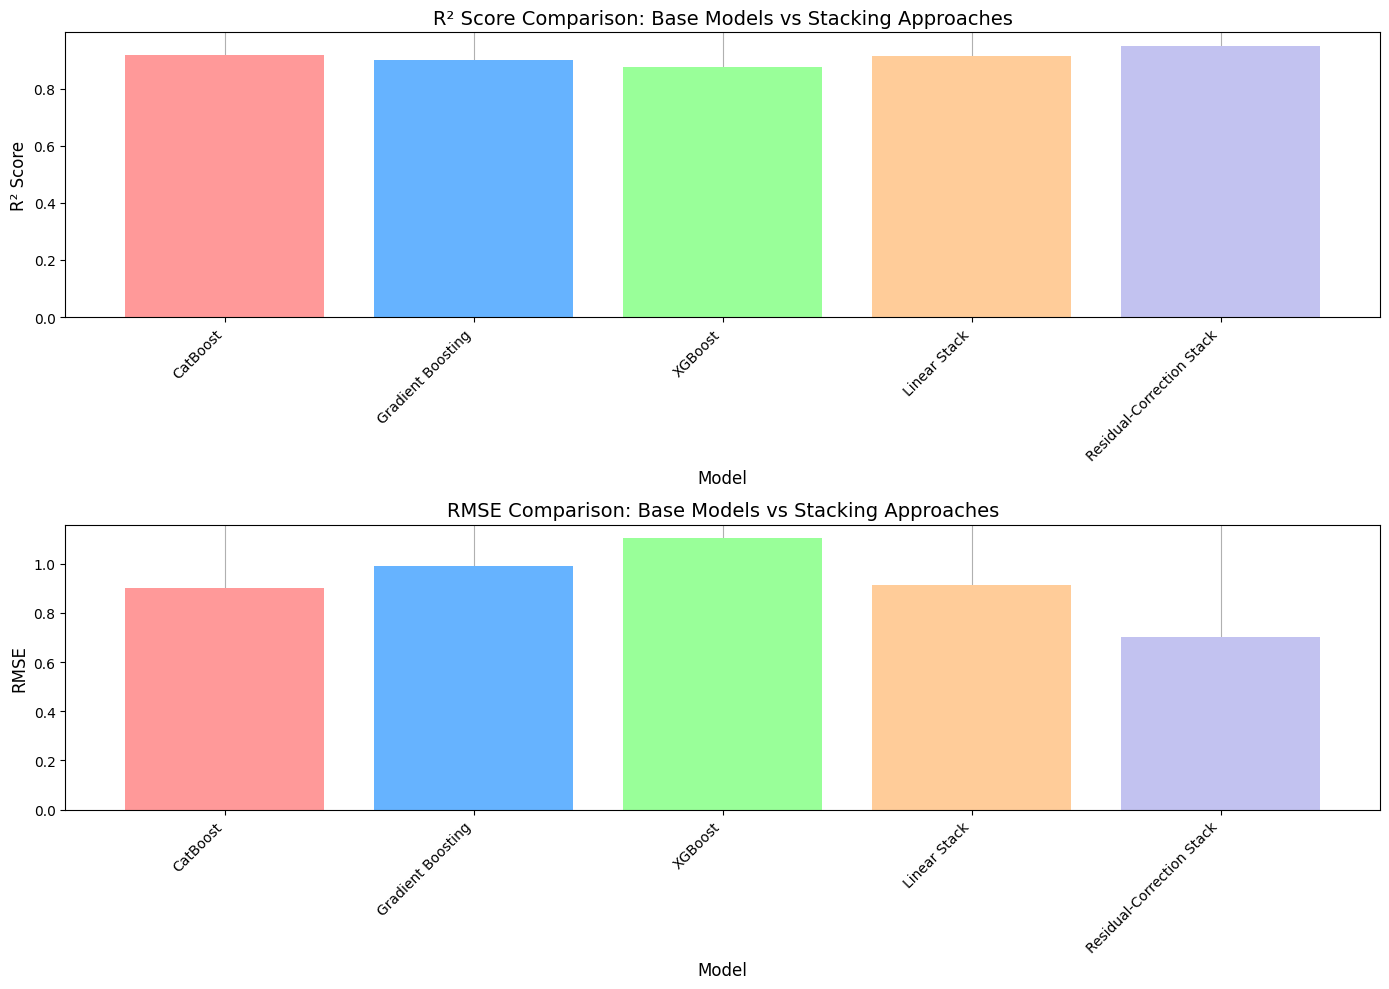


🏆 Best Overall Model: Residual-Correction Stack
   R²: 0.9498 | RMSE: 0.7038

🏆 Best stacking approach: Residual-Correction Stack
🏆 Best base model: CatBoost
Improvement with Residual-Correction Stack:
R² improvement: 3.49%
RMSE improvement: 21.86%


In [18]:
# 7- Implement focused stacking approaches
def implement_focused_stacking(X_train, S_train, X_test, S_test, y_train, y_test, base_model_metrics):
    """
    Implement two key stacking approaches:
    1. Linear Stack: Simple linear meta-model
    2. Residual-Correction Stack: Focuses on correcting residuals from the best base model
    """
    print("\n🔄 Training focused stacking approaches...")
    
    # Set seed for reproducibility
    np.random.seed(RANDOM_STATE)
    
    stacking_results = {}
    
    # Approach 1: Linear Stack
    print("\nTraining Linear Stack...")
    linear_stack = Lasso(alpha=0.001, random_state=RANDOM_STATE)
    linear_stack.fit(S_train, y_train)
    
    # Make predictions
    linear_preds = linear_stack.predict(S_test)
    
    # Evaluate
    mse, rmse, mae, r2 = compute_metrics(y_test, linear_preds)
    stacking_results["Linear Stack"] = {
        "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2
    }
    
    # Save the model
    model_path = f"../stacked_models/linear_stack_model.joblib"
    joblib.dump(linear_stack, model_path)
    print(f"  💾 Linear Stack model saved to {model_path}")
    print(f"  ✅ Linear Stack performance:")
    print(f"     MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    
    # Approach 2: Residual-Correction Stack
    print("\nTraining Residual-Correction Stack...")
    
    # Find the best base model
    best_base_model_name = base_model_metrics['Test_R2'].idxmax()
    best_model_idx = list(base_models.keys()).index(best_base_model_name)
    
    # Get best model predictions on training data
    best_model_train_preds = S_train[:, best_model_idx]
    
    # Calculate residuals for each training example
    train_residuals = np.abs(best_model_train_preds - y_train.values)
    
    # Create a secondary model specifically trained to predict the residuals
    residual_model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
    residual_model.fit(X_train, train_residuals)
    
    # Predict residuals on test set
    best_model_test_preds = S_test[:, best_model_idx]
    predicted_residuals = residual_model.predict(X_test)
    
    # Find direction of residuals (+ or -) using a simple heuristic
    residual_direction = np.sign(y_test.values - best_model_test_preds)
    
    # Correct predictions by subtracting or adding the predicted residual
    corrected_preds = best_model_test_preds + (residual_direction * predicted_residuals * 0.5)
    
    mse, rmse, mae, r2 = compute_metrics(y_test, corrected_preds)
    stacking_results["Residual-Correction Stack"] = {
        "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2
    }
    
    joblib.dump(residual_model, "../stacked_models/residual_correction_stack_model.joblib")
    print(f"  💾 Residual-Correction Stack model saved")
    print(f"  ✅ Residual-Correction Stack performance:")
    print(f"     MSE: {mse:.4f} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")
    
    return pd.DataFrame.from_dict(stacking_results, orient='index')

# Set seed for reproducibility
np.random.seed(RANDOM_STATE)

# Train the stacking approaches
stacking_results = implement_focused_stacking(X_train, S_train, X_test, S_test, y_train, y_test, base_model_metrics)

# Display stacking results with all metrics
print("\n📋 Stacking Approaches Performance (All Metrics):")
display(stacking_results)

# Plot stacking model R2 scores with distinct colors
# plt.figure(figsize=(10, 5))
# plt.barh(stacking_results.index, stacking_results['R2'], color=['#ff9999', '#66b3ff'])
# plt.xlabel('R² Score')
# plt.title('Stacking Approaches - R² Scores')
# plt.grid(axis='x')
# plt.tight_layout()
# plt.savefig('../results_fig/stacking_approaches_r2_scores.png')
# plt.show()

# Compare stacking approaches with top 3 base models
print("\n📊 Comparing Stacking Approaches with Top 3 Base Models:")

# Get top 3 base models
top3_base_models = base_model_metrics.sort_values(by='Test_R2', ascending=False).head(3)
top3_names = top3_base_models.index.tolist()
top3_r2 = top3_base_models['Test_R2'].tolist()
top3_rmse = top3_base_models['Test_RMSE'].tolist()

# Create comparison table
comparison_data = []
for i, model in enumerate(top3_names):
    comparison_data.append({
        'Model': model,
        'Type': 'Base Model',
        'R2': top3_r2[i],
        'RMSE': top3_rmse[i]
    })

# Add stacking models to comparison
for model in stacking_results.index:
    comparison_data.append({
        'Model': model,
        'Type': 'Stacking Model',
        'R2': stacking_results.loc[model, 'R2'],
        'RMSE': stacking_results.loc[model, 'RMSE']
    })

comparison_df = pd.DataFrame(comparison_data)
display(comparison_df)

# Plot comparison with unique colors for each model
plt.figure(figsize=(14, 10))

# Define a list of distinct colors for all models
distinct_colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

# R² comparison
plt.subplot(2, 1, 1)
bars = plt.bar(comparison_df['Model'], comparison_df['R2'], color=distinct_colors[:len(comparison_df)])
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('R² Score Comparison: Base Models vs Stacking Approaches')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

# RMSE comparison
plt.subplot(2, 1, 2)
bars = plt.bar(comparison_df['Model'], comparison_df['RMSE'], color=distinct_colors[:len(comparison_df)])
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.title('RMSE Comparison: Base Models vs Stacking Approaches')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')

plt.tight_layout()
plt.savefig('../results_fig/stacking_vs_top3_comparison.png')
plt.show()

# Find the overall best model
all_models_r2 = {}
all_models_rmse = {}

# Add base models
for model in base_model_metrics.index:
    all_models_r2[model] = base_model_metrics.loc[model, 'Test_R2']
    all_models_rmse[model] = base_model_metrics.loc[model, 'Test_RMSE']
    
# Add stacking models
for model in stacking_results.index:
    all_models_r2[model] = stacking_results.loc[model, 'R2']
    all_models_rmse[model] = stacking_results.loc[model, 'RMSE']

# Find best model
best_model = max(all_models_r2.items(), key=lambda x: x[1])
best_model_name, best_r2 = best_model
best_rmse = all_models_rmse[best_model_name]

print(f"\n🏆 Best Overall Model: {best_model_name}")
print(f"   R²: {best_r2:.4f} | RMSE: {best_rmse:.4f}")

# Calculate improvements of best stacking approach over best base model
best_stack_model = stacking_results['R2'].idxmax()
best_stack_r2 = stacking_results.loc[best_stack_model, 'R2']
best_stack_rmse = stacking_results.loc[best_stack_model, 'RMSE']

best_base = base_model_metrics['Test_R2'].idxmax()
best_base_r2 = base_model_metrics.loc[best_base, 'Test_R2']
best_base_rmse = base_model_metrics.loc[best_base, 'Test_RMSE']

improvement_r2 = (best_stack_r2 - best_base_r2) / best_base_r2 * 100
improvement_rmse = (best_base_rmse - best_stack_rmse) / best_base_rmse * 100

print(f"\n🏆 Best stacking approach: {best_stack_model}")
print(f"🏆 Best base model: {best_base}")
print(f"Improvement with {best_stack_model}:")
print(f"R² improvement: {improvement_r2:.2f}%")
print(f"RMSE improvement: {improvement_rmse:.2f}%")


📊 Creating comprehensive evaluation metric tables...

Calculating base model metrics on training set...

Calculating stacking model metrics on training set...

🔍 TRAINING SET METRICS FOR ALL MODELS:


,MSE,RMSE,MAE,R2
CatBoost,0.1460,0.3821,0.1504,0.9834
Residual-Correction Stack,0.1730,0.4160,0.3232,0.9803
XGBoost,0.1840,0.4289,0.1503,0.9791
Gradient Boosting,0.1956,0.4423,0.2047,0.9778
LightGBM,0.3191,0.5649,0.3261,0.9637
Decision Tree,0.4584,0.6770,0.1965,0.9479
Random Forest,0.4718,0.6869,0.4687,0.9464
Linear Stack,0.9501,0.9747,0.6722,0.8920
SVR,2.8000,1.6733,1.2282,0.6818
KNN Regression,2.9148,1.7073,1.3852,0.6688



🔍 TEST SET METRICS FOR ALL MODELS:


,MSE,RMSE,MAE,R2
Residual-Correction Stack,0.4954,0.7038,0.3927,0.9498
CatBoost,0.8113,0.9007,0.5478,0.9178
Linear Stack,0.8324,0.9123,0.5889,0.9157
Gradient Boosting,0.9847,0.9923,0.6319,0.9002
XGBoost,1.2164,1.1029,0.8151,0.8768
Random Forest,1.4379,1.1991,0.8293,0.8543
LightGBM,1.7576,1.3258,0.9739,0.8219
Decision Tree,3.1341,1.7703,0.9199,0.6825
SVR,3.6418,1.9084,1.4700,0.6311
KNN Regression,3.6704,1.9158,1.5280,0.6282



💾 Metrics tables saved to CSV files


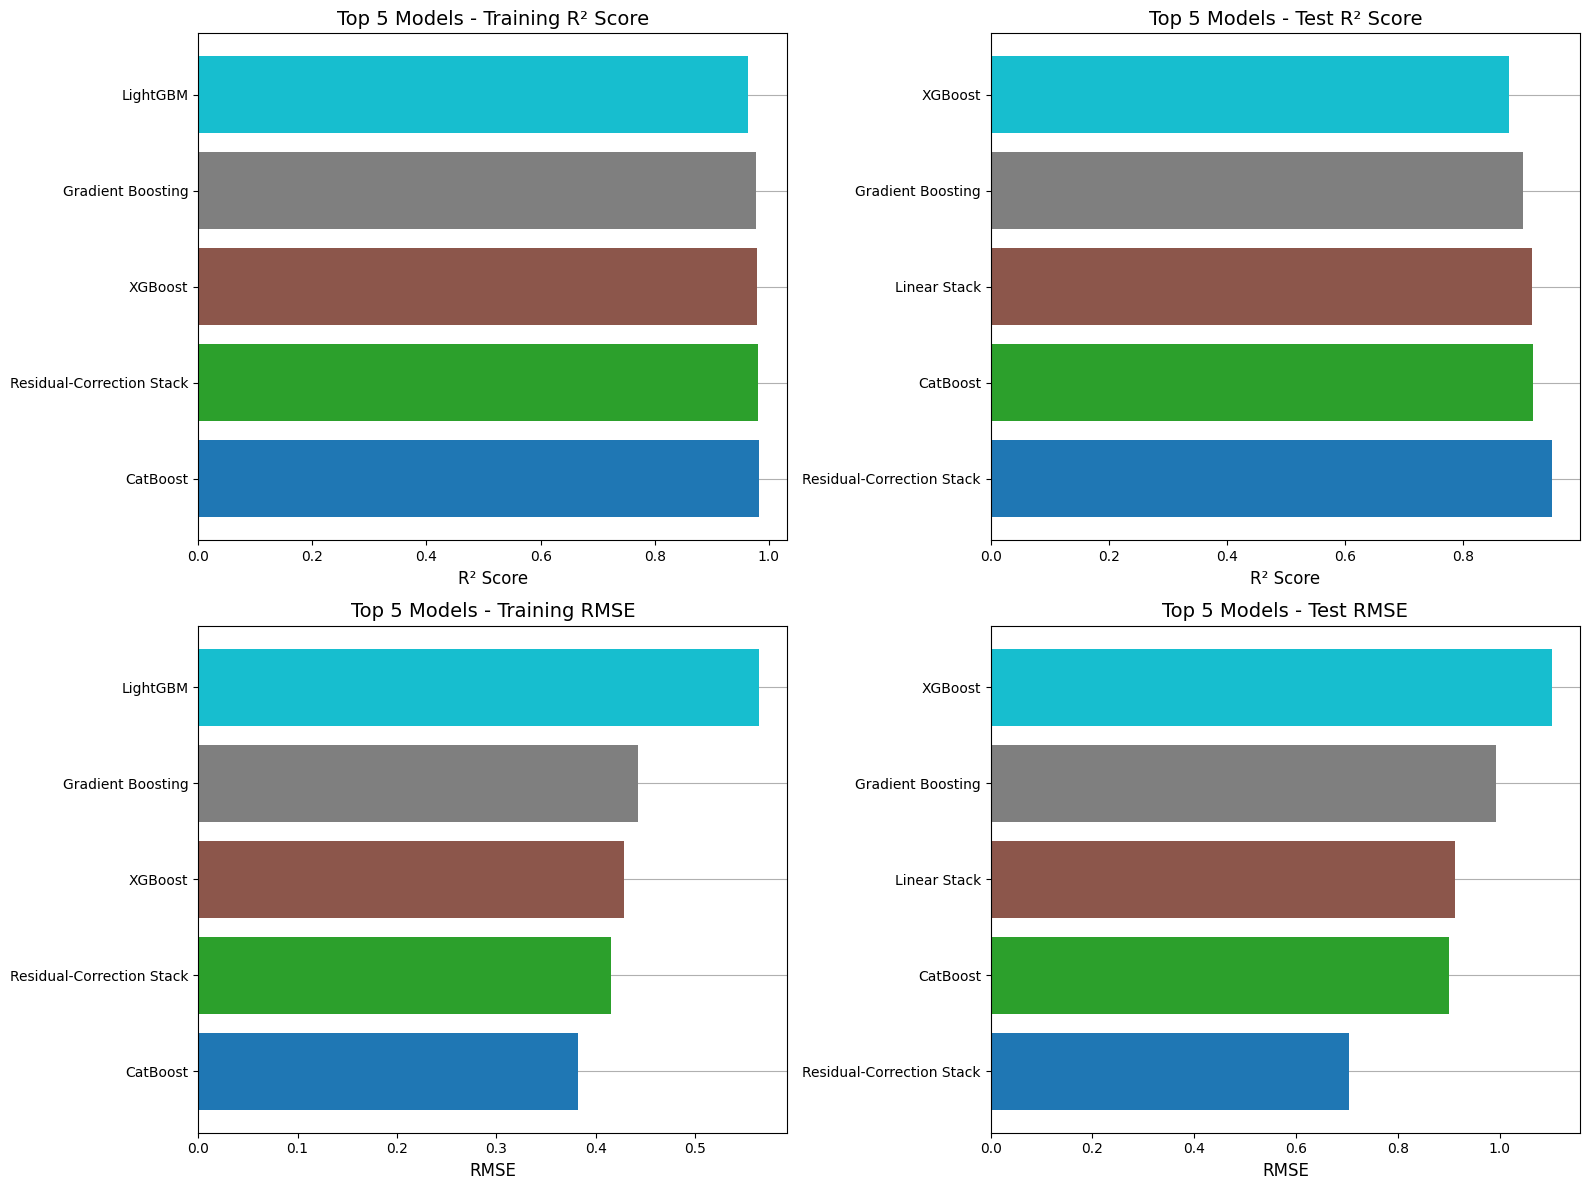

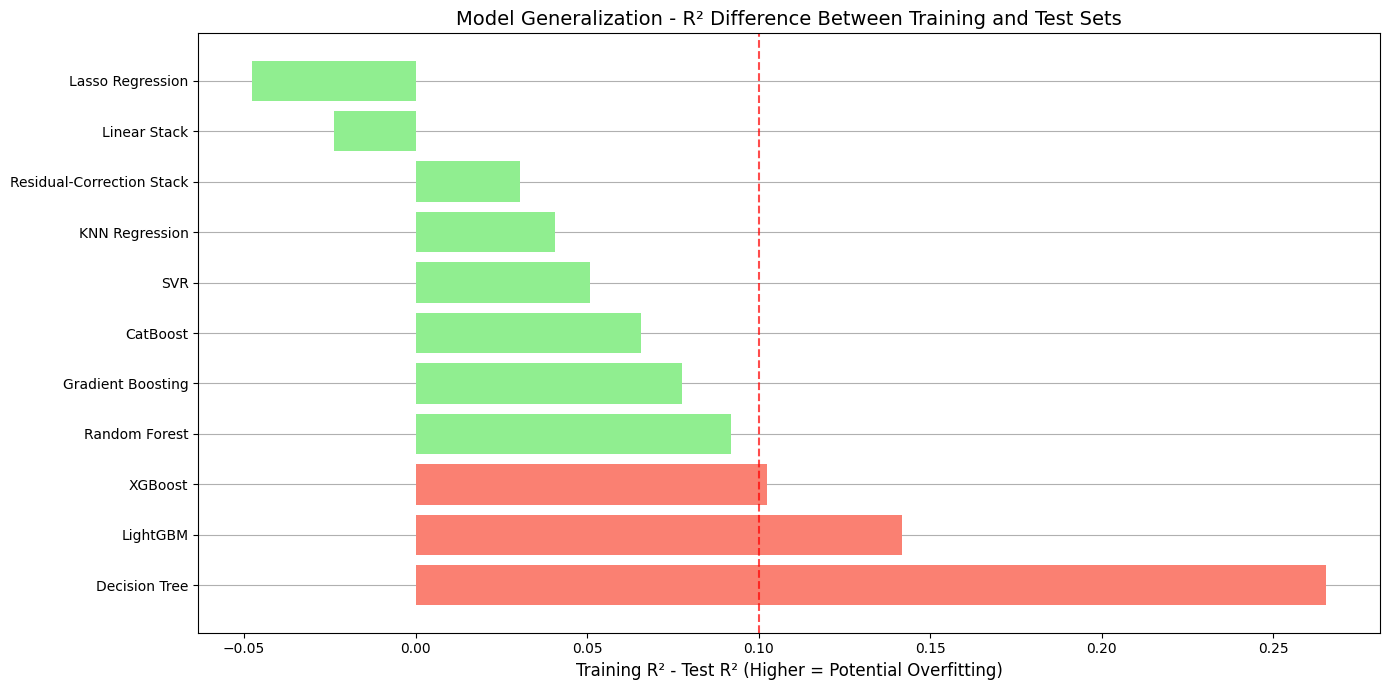

In [19]:
# 8- Create comprehensive evaluation metric tables for all models
def create_comprehensive_tables(base_models, X_train, S_train, X_test, S_test, y_train, y_test, 
                               base_model_metrics, stacking_results):
    """
    Create comprehensive tables showing all evaluation metrics for:
    1. All base models
    2. All stacking models
    For both training and test sets
    """
    print("\n📊 Creating comprehensive evaluation metric tables...")
    
    # Create empty DataFrames for both tables
    train_metrics = pd.DataFrame(columns=['MSE', 'RMSE', 'MAE', 'R2'])
    test_metrics = pd.DataFrame(columns=['MSE', 'RMSE', 'MAE', 'R2'])
    
    # Calculate training metrics for base models
    print("\nCalculating base model metrics on training set...")
    for name, model in base_models.items():
        # Load the best fold model for each base model
        try:
            model_path = f"../base_models/{name.lower().replace(' ', '_')}_best_fold_" + \
                        f"{int(base_model_metrics.loc[name, 'Best_Fold'])}_model.joblib"
            loaded_model = joblib.load(model_path)
            
            # Generate predictions on training set
            train_preds = loaded_model.predict(X_train)
            
            # Calculate metrics
            mse, rmse, mae, r2 = compute_metrics(y_train, train_preds)
            train_metrics.loc[name] = [mse, rmse, mae, r2]
            
        except Exception as e:
            print(f"Error calculating training metrics for {name}: {e}")
            train_metrics.loc[name] = [np.nan, np.nan, np.nan, np.nan]
    
    # Add test metrics for base models from existing results
    for name in base_models.keys():
        test_metrics.loc[name] = [
            base_model_metrics.loc[name, 'Test_MSE'],
            base_model_metrics.loc[name, 'Test_RMSE'],
            base_model_metrics.loc[name, 'Test_MAE'],
            base_model_metrics.loc[name, 'Test_R2']
        ]
    
    # Calculate training metrics for stacking models
    print("\nCalculating stacking model metrics on training set...")
    stack_models = {}
    
    # Load Linear Stack model
    try:
        linear_model = joblib.load("../stacked_models/linear_stack_model.joblib")
        train_preds = linear_model.predict(S_train)
        mse, rmse, mae, r2 = compute_metrics(y_train, train_preds)
        train_metrics.loc["Linear Stack"] = [mse, rmse, mae, r2]
        stack_models["Linear Stack"] = linear_model
    except Exception as e:
        print(f"Error calculating training metrics for Linear Stack: {e}")
        train_metrics.loc["Linear Stack"] = [np.nan, np.nan, np.nan, np.nan]
    
    # Load Residual-Correction Stack model and recalculate predictions
    try:
        residual_model = joblib.load("../stacked_models/residual_correction_stack_model.joblib")
        
        # Need to recalculate the process for training set
        best_base_model_name = base_model_metrics['Test_R2'].idxmax()
        best_model_idx = list(base_models.keys()).index(best_base_model_name)
        best_model_path = f"../base_models/{best_base_model_name.lower().replace(' ', '_')}_best_fold_" + \
                         f"{int(base_model_metrics.loc[best_base_model_name, 'Best_Fold'])}_model.joblib"
        best_model = joblib.load(best_model_path)
        
        # Get best model predictions on training data
        best_model_train_preds = best_model.predict(X_train)
        
        # Predict residuals on training set
        predicted_residuals = residual_model.predict(X_train)
        
        # Find direction of residuals
        residual_direction = np.sign(y_train.values - best_model_train_preds)
        
        # Correct predictions
        corrected_train_preds = best_model_train_preds + (residual_direction * predicted_residuals * 0.5)
        
        # Calculate metrics
        mse, rmse, mae, r2 = compute_metrics(y_train, corrected_train_preds)
        train_metrics.loc["Residual-Correction Stack"] = [mse, rmse, mae, r2]
        stack_models["Residual-Correction Stack"] = residual_model
    except Exception as e:
        print(f"Error calculating training metrics for Residual-Correction Stack: {e}")
        train_metrics.loc["Residual-Correction Stack"] = [np.nan, np.nan, np.nan, np.nan]
    
    # Add test metrics for stacking models from existing results
    for name in stacking_results.index:
        test_metrics.loc[name] = [
            stacking_results.loc[name, 'MSE'],
            stacking_results.loc[name, 'RMSE'],
            stacking_results.loc[name, 'MAE'],
            stacking_results.loc[name, 'R2']
        ]
    
    # Sort tables by R2 score
    train_metrics = train_metrics.sort_values(by='R2', ascending=False)
    test_metrics = test_metrics.sort_values(by='R2', ascending=False)
    
    # Create a better visual format for tables
    def style_table(df):
        return df.style.format({
            'MSE': '{:.4f}',
            'RMSE': '{:.4f}',
            'MAE': '{:.4f}',
            'R2': '{:.4f}'
        }).background_gradient(cmap='viridis', subset=['R2'])
    
    # Print complete tables
    print("\n🔍 TRAINING SET METRICS FOR ALL MODELS:")
    display(style_table(train_metrics))
    
    print("\n🔍 TEST SET METRICS FOR ALL MODELS:")
    display(style_table(test_metrics))
    
    # Save tables to CSV
    train_metrics.to_csv("../results_fig/training_metrics_all_models.csv")
    test_metrics.to_csv("../results_fig/test_metrics_all_models.csv")
    print(f"\n💾 Metrics tables saved to CSV files")
    
    return train_metrics, test_metrics

# Execute the function to create comprehensive tables
train_metrics_table, test_metrics_table = create_comprehensive_tables(
    base_models, X_train, S_train, X_test, S_test, y_train, y_test, 
    base_model_metrics, stacking_results
)

# Create bar plots comparing top 5 models on both training and test sets
plt.figure(figsize=(16, 12))

# Training set R2 for top 5 models
plt.subplot(2, 2, 1)
top5_train = train_metrics_table.head(5)
colors = plt.cm.tab10(np.linspace(0, 1, len(top5_train)))
plt.barh(top5_train.index, top5_train['R2'], color=colors)
plt.xlabel('R² Score')
plt.title('Top 5 Models - Training R² Score')
plt.grid(axis='x')

# Test set R2 for top 5 models
plt.subplot(2, 2, 2)
top5_test = test_metrics_table.head(5)
colors = plt.cm.tab10(np.linspace(0, 1, len(top5_test)))
plt.barh(top5_test.index, top5_test['R2'], color=colors)
plt.xlabel('R² Score')
plt.title('Top 5 Models - Test R² Score')
plt.grid(axis='x')

# Training set RMSE for top 5 models
plt.subplot(2, 2, 3)
plt.barh(top5_train.index, top5_train['RMSE'], color=colors)
plt.xlabel('RMSE')
plt.title('Top 5 Models - Training RMSE')
plt.grid(axis='x')

# Test set RMSE for top 5 models
plt.subplot(2, 2, 4)
plt.barh(top5_test.index, top5_test['RMSE'], color=colors)
plt.xlabel('RMSE')
plt.title('Top 5 Models - Test RMSE')
plt.grid(axis='x')

plt.tight_layout()
plt.savefig('../results_fig/top5_train_test_comparison.png')
plt.show()

# Check for potential overfitting by comparing train vs test metrics
plt.figure(figsize=(14, 7))

# Calculate the difference between training and test R2 scores
r2_diff = {}
for model in set(train_metrics_table.index) & set(test_metrics_table.index):
    r2_diff[model] = train_metrics_table.loc[model, 'R2'] - test_metrics_table.loc[model, 'R2']

r2_diff = pd.Series(r2_diff).sort_values(ascending=False)

# Plot the R2 difference (higher values suggest more overfitting)
colors = ['salmon' if x > 0.1 else 'lightgreen' for x in r2_diff.values]
plt.barh(r2_diff.index, r2_diff.values, color=colors)
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Training R² - Test R² (Higher = Potential Overfitting)')
plt.title('Model Generalization - R² Difference Between Training and Test Sets')
plt.grid(axis='x')
plt.tight_layout()
plt.savefig('../results_fig/model_generalization.png')
plt.show()


🎨 Creating advanced generalization visualizations...


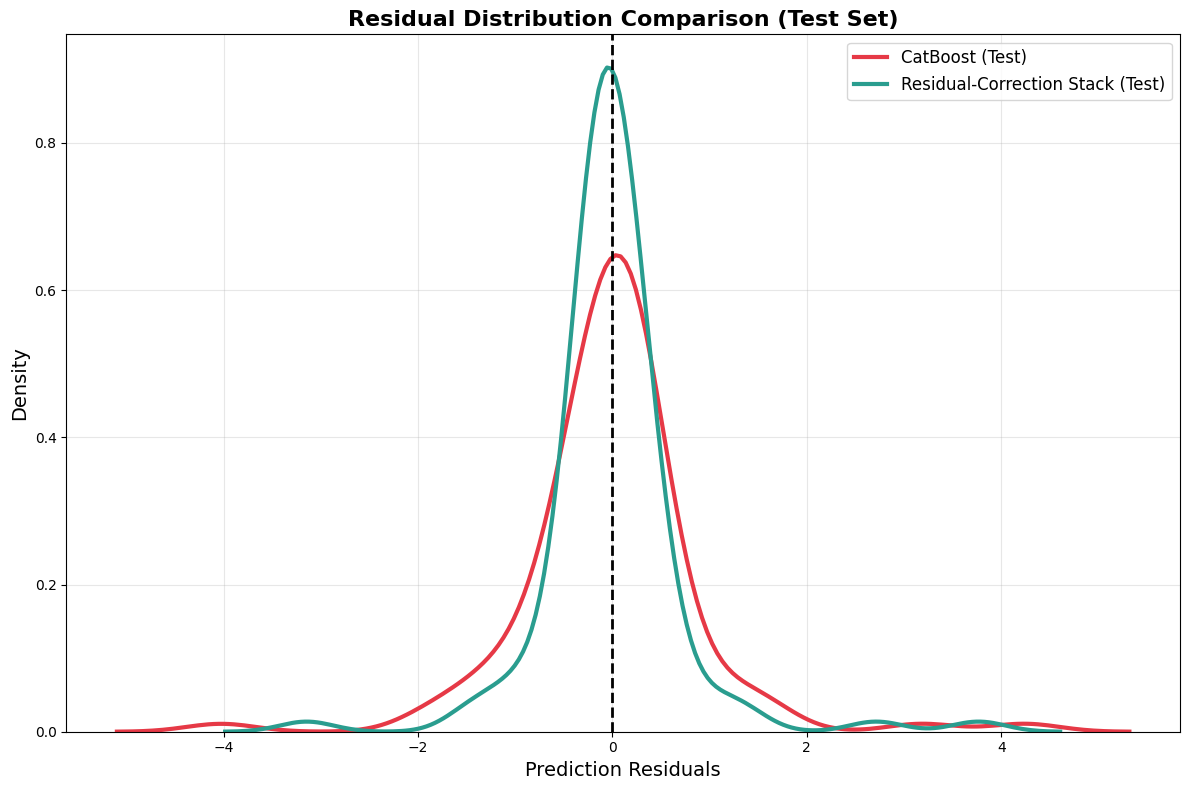

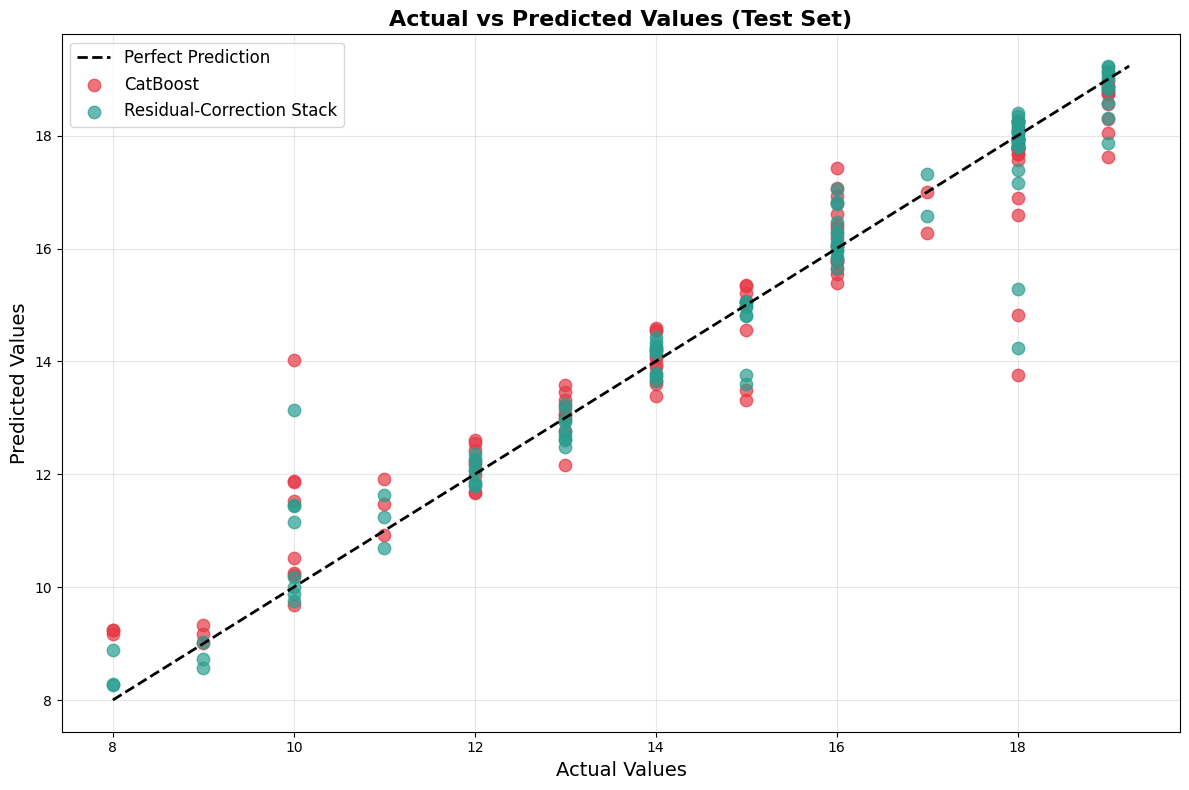

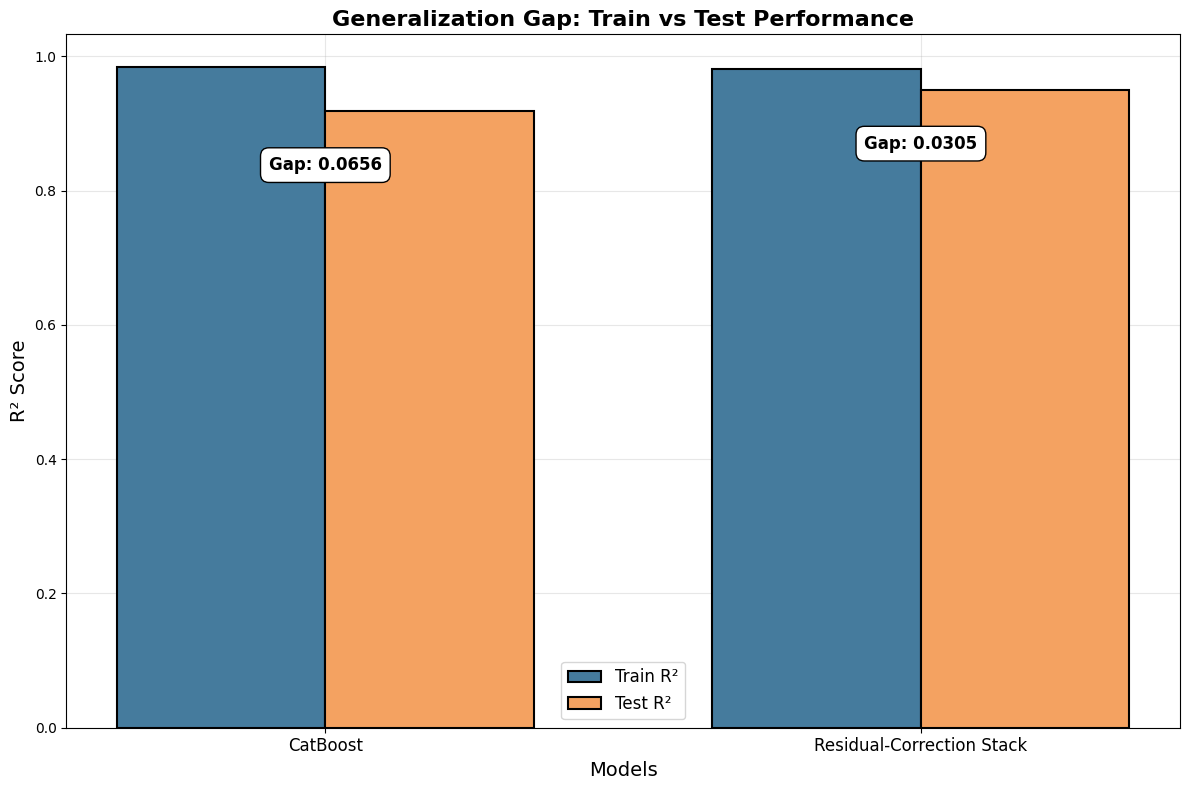

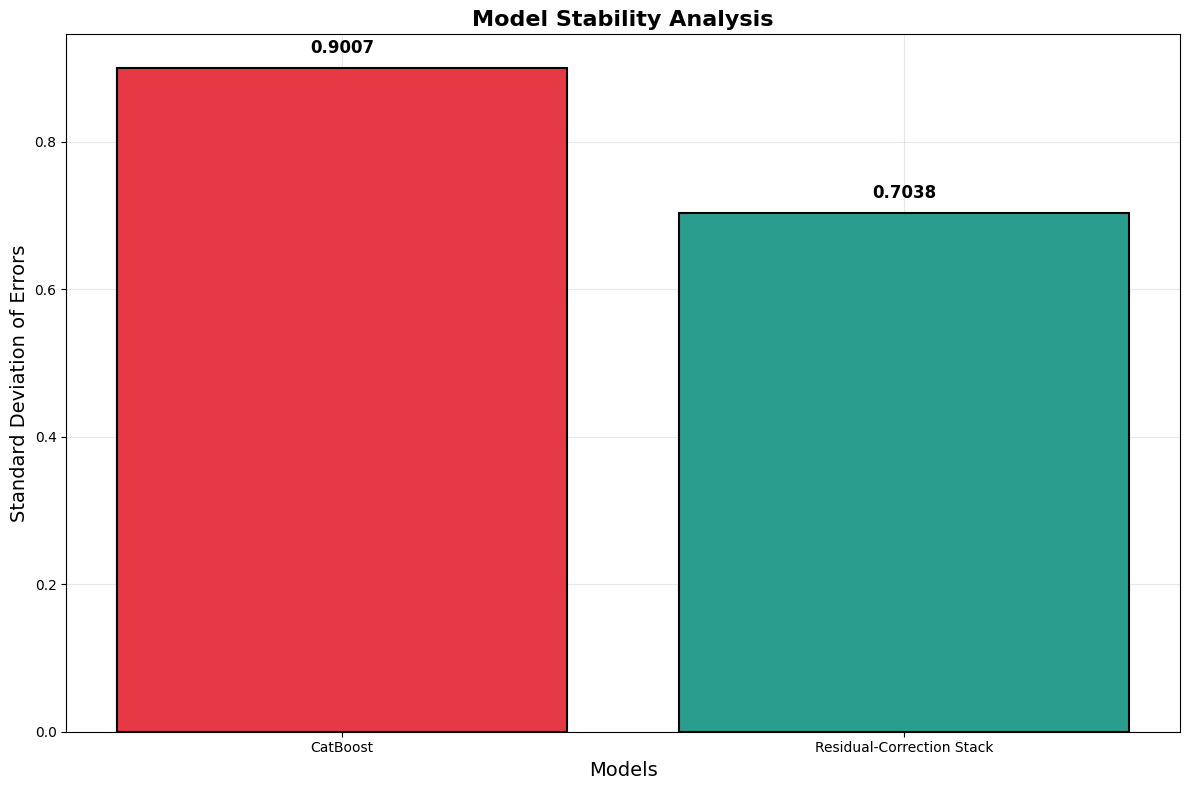

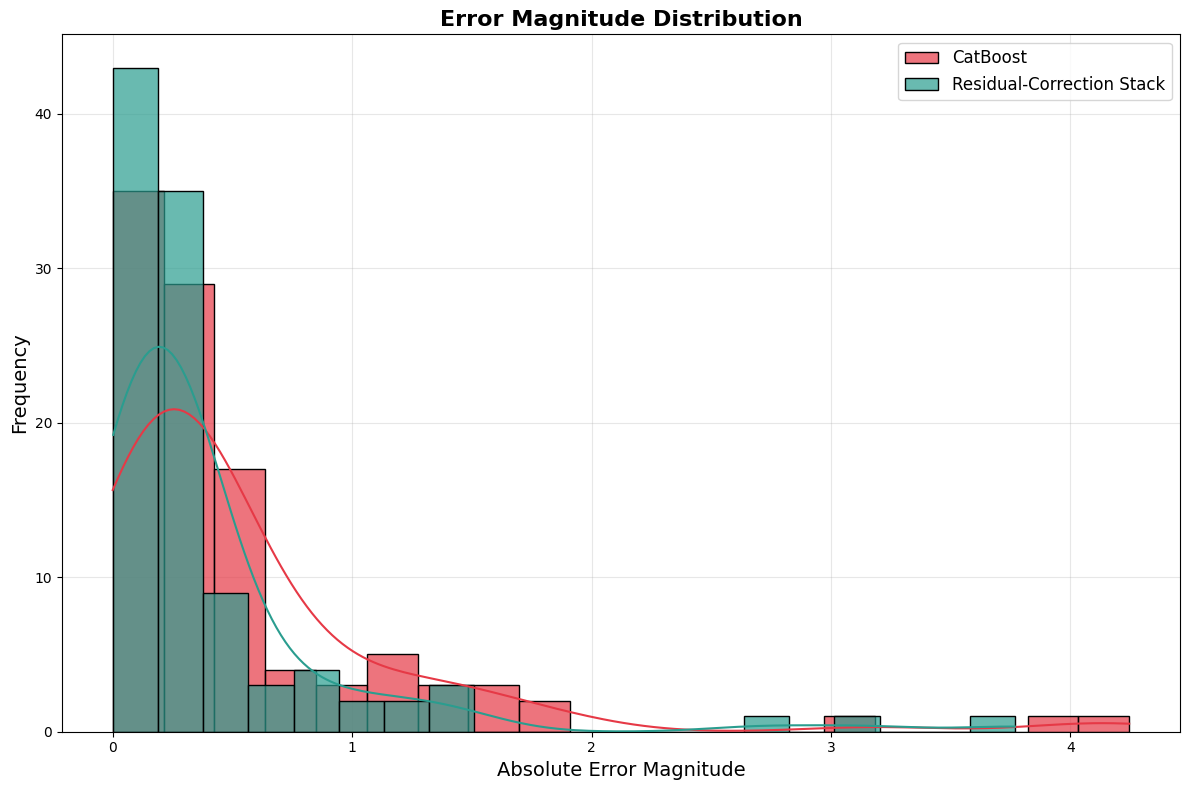

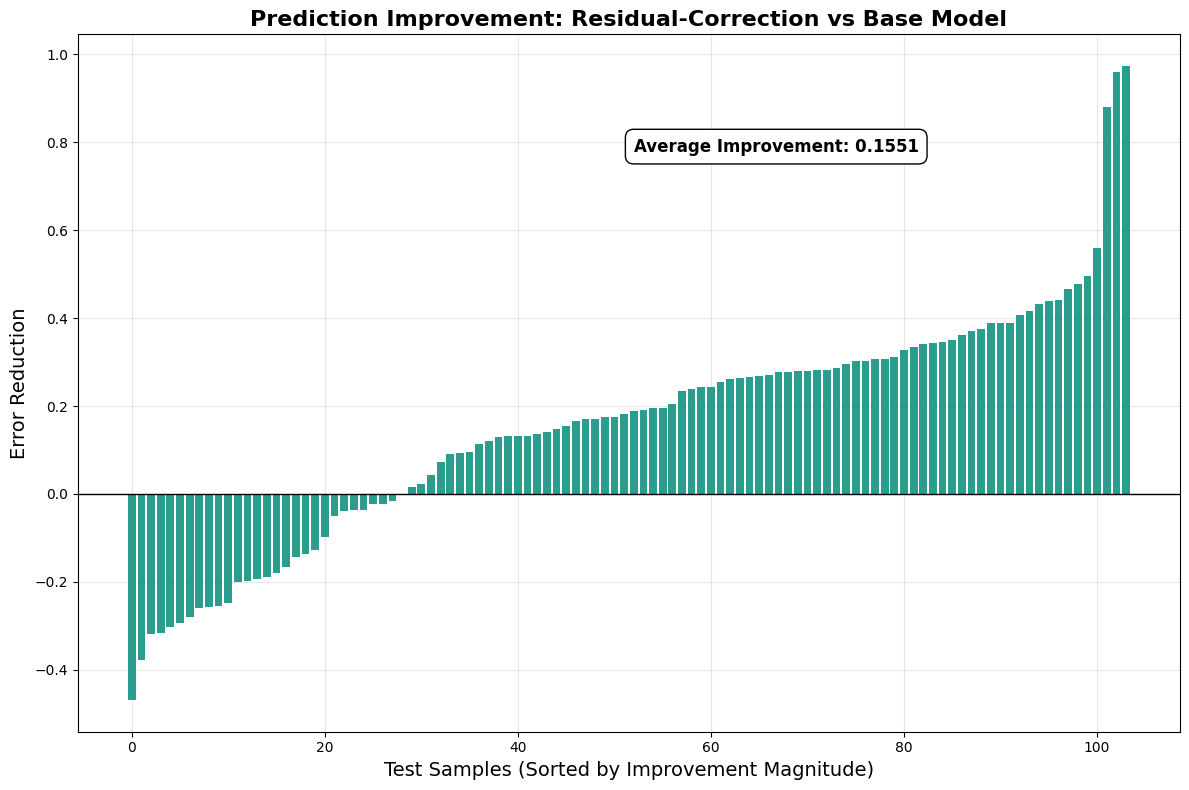


✅ Generalization visualizations completed and saved as separate images


In [23]:
# 9- Advanced visualizations for model generalization with only best models
def create_generalization_visualizations(base_models, X_train, X_test, y_train, y_test, 
                                         base_model_metrics, stacking_results):
    """
    Create advanced visualizations to showcase model generalization,
    comparing only the best base model and Residual-Correction Stack.
    """
    # Add necessary imports at the beginning of the function
    import matplotlib.pyplot as plt
    import seaborn as sns
    from sklearn.utils import resample
    
    print("\n🎨 Creating advanced generalization visualizations...")
    
    # Define strong, distinct colors for two models
    colors = {
        'base': '#E63946',     # Strong red
        'residual': '#2A9D8F'  # Teal green
    }
    
    # Load best base model and residual correction model
    best_base_name = base_model_metrics['Test_R2'].idxmax()
    best_base_fold = int(base_model_metrics.loc[best_base_name, 'Best_Fold'])
    best_base_path = f"../base_models/{best_base_name.lower().replace(' ', '_')}_best_fold_{best_base_fold}_model.joblib"
    best_base_model = joblib.load(best_base_path)
    
    residual_model = joblib.load("../stacked_models/residual_correction_stack_model.joblib")
    
    # Get predictions for the models
    base_train_preds = best_base_model.predict(X_train)
    base_test_preds = best_base_model.predict(X_test)
    
    # For Residual-Correction Stack
    try:
        # Predict residuals
        predicted_train_residuals = residual_model.predict(X_train)
        predicted_test_residuals = residual_model.predict(X_test)
        
        # Apply correction
        train_residual_direction = np.sign(y_train.values - base_train_preds)
        test_residual_direction = np.sign(y_test.values - base_test_preds)
        
        residual_train_preds = base_train_preds + (train_residual_direction * predicted_train_residuals * 0.5)
        residual_test_preds = base_test_preds + (test_residual_direction * predicted_test_residuals * 0.5)
    except Exception as e:
        print(f"Error calculating Residual-Correction Stack predictions: {e}")
        residual_train_preds = np.zeros_like(base_train_preds)
        residual_test_preds = np.zeros_like(base_test_preds)
    
    # 1. Residual Distribution Comparison - As separate image
    plt.figure(figsize=(12, 8))
    
    base_train_residuals = y_train - base_train_preds
    base_test_residuals = y_test - base_test_preds
    residual_train_residuals = y_train - residual_train_preds
    residual_test_residuals = y_test - residual_test_preds
    
    sns.kdeplot(base_test_residuals, color=colors['base'], label=f'{best_base_name} (Test)', linewidth=3)
    sns.kdeplot(residual_test_residuals, color=colors['residual'], label='Residual-Correction Stack (Test)', linewidth=3)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
    plt.xlabel('Prediction Residuals', fontsize=14)
    plt.ylabel('Density', fontsize=14)
    plt.title('Residual Distribution Comparison (Test Set)', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results_fig/residual_distribution.png', dpi=300)
    plt.show()
    
    # 2. Actual vs Predicted Scatter - As separate image
    plt.figure(figsize=(12, 8))
    
    # Plot diagonal line (perfect predictions)
    min_val = min(min(y_test), min(base_test_preds), min(residual_test_preds))
    max_val = max(max(y_test), max(base_test_preds), max(residual_test_preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect Prediction')
    
    # Scatter plots with larger markers and stronger colors
    plt.scatter(y_test, base_test_preds, alpha=0.7, color=colors['base'], s=80, label=f'{best_base_name}')
    plt.scatter(y_test, residual_test_preds, alpha=0.7, color=colors['residual'], s=80, label='Residual-Correction Stack')
    
    plt.xlabel('Actual Values', fontsize=14)
    plt.ylabel('Predicted Values', fontsize=14)
    plt.title('Actual vs Predicted Values (Test Set)', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results_fig/actual_vs_predicted.png', dpi=300)
    plt.show()
    
    # 3. Generalization Gap Visualization - As separate image
    plt.figure(figsize=(12, 8))
    
    models = [best_base_name, 'Residual-Correction Stack']
    train_r2 = []
    test_r2 = []
    
    # Calculate R2 scores
    for model_name, train_preds, test_preds in [
        (best_base_name, base_train_preds, base_test_preds),
        ('Residual-Correction Stack', residual_train_preds, residual_test_preds)
    ]:
        _, _, _, train_r2_val = compute_metrics(y_train, train_preds)
        _, _, _, test_r2_val = compute_metrics(y_test, test_preds)
        train_r2.append(train_r2_val)
        test_r2.append(test_r2_val)
    
    # Calculate generalization gap
    gen_gap = np.array(train_r2) - np.array(test_r2)
    
    # Create the bar plot with stronger colors
    model_colors = [colors['base'], colors['residual']]
    
    x = np.arange(len(models))
    width = 0.35
    
    plt.bar(x - width/2, train_r2, width, label='Train R²', color='#457B9D', edgecolor='black', linewidth=1.5)
    plt.bar(x + width/2, test_r2, width, label='Test R²', color='#F4A261', edgecolor='black', linewidth=1.5)
    
    # Add gap annotations with clearer formatting
    for i in range(len(models)):
        plt.text(i, min(train_r2[i], test_r2[i]) - 0.08, 
                 f'Gap: {gen_gap[i]:.4f}', 
                 ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
    
    plt.xlabel('Models', fontsize=14)
    plt.ylabel('R² Score', fontsize=14)
    plt.title('Generalization Gap: Train vs Test Performance', fontsize=16, fontweight='bold')
    plt.xticks(x, models, fontsize=12)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results_fig/generalization_gap.png', dpi=300)
    plt.show()
    
    # 4. Model Stability Analysis - As separate image
    plt.figure(figsize=(12, 8))
    
    # Calculate standard deviation of errors for stability assessment
    std_base = np.std(y_test.values - base_test_preds)
    std_residual = np.std(y_test.values - residual_test_preds)
    
    stds = [std_base, std_residual]
    
    # Create bar plot with stronger colors
    plt.bar(models, stds, color=model_colors, edgecolor='black', linewidth=1.5)
    plt.xlabel('Models', fontsize=14)
    plt.ylabel('Standard Deviation of Errors', fontsize=14)
    plt.title('Model Stability Analysis', fontsize=16, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Add value labels with better formatting
    for i, v in enumerate(stds):
        plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../results_fig/model_stability.png', dpi=300)
    plt.show()
    
    # 5. Error Distribution by Magnitude - Bonus visualization
    plt.figure(figsize=(12, 8))
    
    # Calculate absolute errors
    base_errors = np.abs(y_test.values - base_test_preds)
    residual_errors = np.abs(y_test.values - residual_test_preds)
    
    # Plot error distributions
    sns.histplot(base_errors, color=colors['base'], alpha=0.7, label=f'{best_base_name}', bins=20, kde=True)
    sns.histplot(residual_errors, color=colors['residual'], alpha=0.7, label='Residual-Correction Stack', bins=20, kde=True)
    
    plt.xlabel('Absolute Error Magnitude', fontsize=14)
    plt.ylabel('Frequency', fontsize=14)
    plt.title('Error Magnitude Distribution', fontsize=16, fontweight='bold')
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results_fig/error_magnitude.png', dpi=300)
    plt.show()
    
    # 6. Prediction Improvement Visualization - New visualization
    plt.figure(figsize=(12, 8))
    
    # Calculate improvement from base to residual-correction
    improvement = base_test_preds - residual_test_preds
    abs_improvement = np.abs(base_test_preds - y_test.values) - np.abs(residual_test_preds - y_test.values)
    
    # Sort by magnitude of improvement for better visualization
    sorted_indices = np.argsort(abs_improvement)
    x_vals = np.arange(len(sorted_indices))
    
    # Plot the improvement
    plt.bar(x_vals, abs_improvement[sorted_indices], color='#2A9D8F' if np.mean(abs_improvement) > 0 else '#E63946')
    plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
    
    plt.xlabel('Test Samples (Sorted by Improvement Magnitude)', fontsize=14)
    plt.ylabel('Error Reduction', fontsize=14)
    plt.title('Prediction Improvement: Residual-Correction vs Base Model', fontsize=16, fontweight='bold')
    
    # Add annotation for average improvement
    mean_improvement = np.mean(abs_improvement)
    plt.annotate(f'Average Improvement: {mean_improvement:.4f}',
                xy=(len(x_vals)*0.5, max(abs_improvement) * 0.8),
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'),
                fontsize=12, fontweight='bold')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('../results_fig/prediction_improvement.png', dpi=300)
    plt.show()
    
    print("\n✅ Generalization visualizations completed and saved as separate images")
    
# Execute the visualization function
create_generalization_visualizations(
    base_models, X_train, X_test, y_train, y_test, 
    base_model_metrics, stacking_results
)